# Coursework1: Convolutional Neural Networks 

## instructions

Please submit a version of this notebook containing your answers **together with your trained model** on CATe as CW1.zip. Write your answers in the cells below each question.

### Setting up working environment 

For this coursework you will need to train a large network, therefore we recommend you work with Google Colaboratory, which provides free GPU time. You will need a Google account to do so. 

Please log in to your account and go to the following page: https://colab.research.google.com. Then upload this notebook.

For GPU support, go to "Edit" -> "Notebook Settings", and select "Hardware accelerator" as "GPU".

You will need to install pytorch by running the following cell:

In [0]:
!pip install torch torchvision

## Introduction

For this coursework you will implement one of the most commonly used model for image recognition tasks, the Residual Network. The architecture is introduced in 2015 by Kaiming He, et al. in the paper ["Deep residual learning for image recognition"](https://www.cv-foundation.org/openaccess/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf). 
<br>

In a residual network, each block contains some convolutional layers, plus "skip" connections, which allow the activations to by pass a layer, and then be summed up with the activations of the skipped layer. The image below illustrates a building block in residual networks.

![resnet-block](utils/resnet-block.png)

Depending on the number of building blocks, resnets can have different architectures, for example ResNet-50, ResNet-101 and etc. Here you are required to build ResNet-18 to perform classification on the CIFAR-10 dataset, therefore your network will have the following architecture:

![resnet](utils/resnet.png)

## Part 1 (40 points)

In this part, you will use basic pytorch operations to define the 2D convolution, max pooling operation, linear layer as well as 2d batch normalization. 

### YOUR TASK

- implement the forward pass for Conv2D, MaxPool2D, Linear and BatchNorm2d
- You are **NOT** allowed to use the torch.nn modules

In [0]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class Conv2d(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size,
                 stride=1,
                 padding=0,
                 bias=True):

        super(Conv2d, self).__init__()
        """
        An implementation of a convolutional layer.

        The input consists of N data points, each with C channels, height H and
        width W. We convolve each input with F different filters, where each filter
        spans all C channels and has height HH and width WW.

        Parameters:
        - w: Filter weights of shape (F, C, HH, WW)
        - b: Biases, of shape (F,)
        - kernel_size: Size of the convolving kernel
        - stride: The number of pixels between adjacent receptive fields in the
            horizontal and vertical directions.
        - padding: The number of pixels that will be used to zero-pad the input.
        """

        ########################################################################
        # TODO: Define the parameters used in the forward pass                 #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size

        if isinstance(stride, int):
            self.stride = (stride, stride)
        else:
            self.stride = stride

        self.padding = padding

        # Initialise weihgts and bias according to Conv2d documentation
        k = math.sqrt(1 / (in_channels * self.kernel_size[0] * \
                           self.kernel_size[1]))
        
        self.w = nn.Parameter(torch.FloatTensor(
            out_channels, 
            in_channels, 
            self.kernel_size[0],
            self.kernel_size[1]).uniform_(-k, k))

        if bias:
            self.b = nn.Parameter(torch.FloatTensor(
                out_channels).uniform_(-k, k))
        else:
            self.b = None

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data, of shape (N, F, H', W').
        """

        ########################################################################
        # TODO: Implement the forward pass                                     #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        N, C, H, W = x.shape
        F, CC, HH, WW = self.w.shape

        assert C == CC, f'Input shape[1] should be equal to {CC}'

        H_out = 1 + (H + 2 * self.padding - HH) // self.stride[0]
        W_out = 1 + (H + 2 * self.padding - WW) // self.stride[1]

        x = nn.functional.unfold(x, kernel_size=self.kernel_size, \
                                       stride=self.stride, padding=self.padding)
        if self.b == None:
            x = (x.transpose(1, 2).matmul(
                self.w.view(F, -1).T)).transpose(1, 2)
        else:
            x = (x.transpose(1, 2).matmul(
                self.w.view(F, -1).T) + self.b).transpose(1, 2)

        out = nn.functional.fold(x, (H_out, W_out), kernel_size=(1,1)) 

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

        return out

In [0]:
# Make sure my implementation matches nn.Conv2d implementation
# -------------------------------------------------------------
x = torch.randn(64,3,32,32)
y = torch.randn(64,3,64,64)

# Set a fixed seed so that initializations match
torch.manual_seed(11)
c = Conv2d(3, 2, 5)

torch.manual_seed(11)
C = nn.Conv2d(3, 2, 5)

print((C(x) - c(x)).abs().max())
print((C(y) - c(y)).abs().max())
# -------------------------------------------------------------

tensor(1.1921e-06, grad_fn=<MaxBackward1>)
tensor(1.1921e-06, grad_fn=<MaxBackward1>)


In [0]:
class MaxPool2d(nn.Module):
    def __init__(self, kernel_size):
        super(MaxPool2d, self).__init__()
        """
        An implementation of a max-pooling layer.

        Parameters:
        - kernel_size: the size of the window to take a max over
        """
        ########################################################################
        # TODO: Define the parameters used in the forward pass                 #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        if isinstance(kernel_size, int):
            self.kernel_size = (kernel_size, kernel_size)
            self.stride = (kernel_size, kernel_size)
        else:
            self.kernel_size = kernel_size
            self.stride = kernel_size

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data, of shape (N, C, H', W').
        """
        ########################################################################
        # TODO: Implement the forward pass                                     #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        
        N, C, H, W = x.shape
        k0 , k1 = self.kernel_size
        H_out = (H - k0) // self.stride[0] + 1
        W_out = (W - k1) // self.stride[1] + 1

        y = F.unfold(x, kernel_size = self.kernel_size, stride=self.stride)
        out = torch.empty((N, C, y.shape[2]))
        for i in range(0, C):
            out[:, i, :] = y[:, i*k0*k1:(i+1)*k0*k1,:].max(dim=1)[0]
        out = F.fold(out, (H_out, W_out), kernel_size=(1,1))

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

        return out

In [0]:
# Make sure my implementation matches nn.MaxPool2d implementation
# -------------------------------------------------------------
x = torch.randn(64,3,32,32)
y = torch.randn(64,3,64,64)

m = MaxPool2d(3)
M = nn.MaxPool2d(3)

print('Check if outputs match:')
print((M(x) - m(x)).abs().max())
print((M(y) - m(y)).abs().max())
# -------------------------------------------------------------

Check if outputs match:
tensor(0.)
tensor(0.)


In [0]:
class Linear(nn.Module):
    def __init__(self, in_channels, out_channels, bias=True):
        super(Linear, self).__init__()
        """
        An implementation of a Linear layer.

        Parameters:
        - weight: the learnable weights of the module of shape (out_channels, in_channels).
        - bias: the learnable bias of the module of shape (out_channels).
        """
        ########################################################################
        # TODO: Define the parameters used in the forward pass                 #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        k = math.sqrt(1 / in_channels) 
        self.weight = nn.Parameter(torch.FloatTensor(
            out_channels, in_channels).uniform_(-k, k))
  
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(
                out_channels).uniform_(-k, k))
        else:
            self.bias = None
   
        self.in_channels = in_channels
        self.out_channels = out_channels

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def forward(self, x):
        """
        Input:
        - x: Input data of shape (N, *, H) where * means any number of additional
        dimensions and H = in_channels
        Output:
        - out: Output data of shape (N, *, H') where * means any number of additional
        dimensions and H' = out_channels
        """
        ########################################################################
        # TODO: Implement the forward pass                                     #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        
        # Returns y = xw.T + b

        N, H = x.shape[0], x.shape[-1]

        assert H == self.in_channels, "Input shape[-1] should be"\
                                            f" equal to {self.in_channels}."
        
        if self.bias == None:
            out = x @ self.weight.T
        else:
            out = x @ self.weight.T + self.bias
            
        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

        return out

In [0]:
# Make sure my implementation matches nn.Linear implementation
# -------------------------------------------------------------
x = torch.randn(64,32,32,3)
y = torch.randn(64,64,64,3)

# Set a fixed seed so that initializations match
torch.manual_seed(11)
l = Linear(3,2)

torch.manual_seed(11)
L = nn.Linear(3,2)
print('Check if outputs match:')
print((L(x) - l(x)).abs().max())
print((L(y) - l(y)).abs().max())

w1 = l.weight
w2 = L.weight
print('\nCheck if weights match:')
print((w1 - w2).abs().max())

b1 = l.bias
b2 = L.bias
print('\nCheck if biases match:')
print((b1 - b2).abs().max())
# -------------------------------------------------------------

Check if outputs match:
tensor(0., grad_fn=<MaxBackward1>)
tensor(0., grad_fn=<MaxBackward1>)

Check if weights match:
tensor(0., grad_fn=<MaxBackward1>)

Check if biases match:
tensor(0., grad_fn=<MaxBackward1>)


In [0]:
class BatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        super(BatchNorm2d, self).__init__()
        """
        An implementation of a Batch Normalization over a mini-batch of 2D inputs.

        The mean and standard-deviation are calculated per-dimension over the
        mini-batches and gamma and beta are learnable parameter vectors of
        size num_features.

        Parameters:
        - num_features: C from an expected input of size (N, C, H, W).
        - eps: a value added to the denominator for numerical stability. Default: 1e-5
        - momentum: momentum – the value used for the running_mean and running_var
        computation. Default: 0.1
        - gamma: the learnable weights of shape (num_features).
        - beta: the learnable bias of the module of shape (num_features).
        """
        ########################################################################
        # TODO: Define the parameters used in the forward pass                 #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        # gamma --> initialise to ones according to nn.Barchnorm2d documentacion
        # beta --> initialise to zeros according to nn.Barchnorm2d documentacion

        self.gamma = nn.Parameter(torch.ones(num_features))
        self.beta = nn.Parameter(torch.zeros(num_features))

        self.num_features = num_features
        self.eps = eps 
        self.momentum = momentum
     
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

    def forward(self, x):
        """
        During training this layer keeps running estimates of its computed mean and
        variance, which are then used for normalization during evaluation.
        Input:
        - x: Input data of shape (N, C, H, W)
        Output:
        - out: Output data of shape (N, C, H, W) (same shape as input)
        """
        ########################################################################
        # TODO: Implement the forward pass                                     #
        #       (be aware of the difference for training and testing)          #
        ########################################################################
        # *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

        N, C, H, W = x.shape

        assert self.num_features == C,"Input shape[1] should be "\
                                            f"equal to {self.num_features}."

        mean = x.mean(axis=(0, 2, 3), keepdims=True)

        var = ((x - mean) ** 2).mean(axis=(0, 2, 3), keepdims=True)

        if self.training:
            y = (x - mean) / torch.sqrt(var + self.eps)
            self.running_mean = (1.0 - self.momentum) * self.running_mean + \
                                    self.momentum * mean.squeeze()
                                
            self.running_var = (1.0 - self.momentum) * self.running_var + \
                                    self.momentum * var.squeeze()
        else:
            y = (x - self.running_mean.reshape(1, self.num_features, 1, 1)) / \
            torch.sqrt(self.running_var.reshape(1, self.num_features, 1, 1) + self.eps)
        

        out = self.gamma.reshape(1, self.num_features, 1, 1) * y + \
                            self.beta.reshape(1, self.num_features, 1, 1)


        # *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
        ########################################################################
        #                             END OF YOUR CODE                         #
        ########################################################################

        return out

In [0]:
# Make sure my implementation matches nn.BatchNorm2d implementation
# -------------------------------------------------------------
x = torch.randn(64,3,32,32)
y = torch.randn(64,3,64,64)

# Set a fixed seed so that initializations match
torch.manual_seed(11)
b = BatchNorm2d(3)

torch.manual_seed(11)
B = nn.BatchNorm2d(3)
print('Check if outputs match:')
print((b(x) - B(x)).abs().max())
print((b(y) - B(y)).abs().max())

w1 = b.gamma
w2 = B.weight
print('\nCheck if weights match:')
print((w1 - w2).abs().max())

b1 = b.beta
b2 = B.bias
print('\nCheck if biases match:')
print((b1 - b2).abs().max())
# -------------------------------------------------------------

Check if outputs match:
tensor(9.5367e-07, grad_fn=<MaxBackward1>)
tensor(9.5367e-07, grad_fn=<MaxBackward1>)

Check if weights match:
tensor(0., grad_fn=<MaxBackward1>)

Check if biases match:
tensor(0., grad_fn=<MaxBackward1>)


## Part 2

In this part, you will train a ResNet-18 defined on the CIFAR-10 dataset. Code for training and evaluation are provided. 

### Your Task

1. Train your network to achieve the best possible test set accuracy after a maximum of 10 epochs of training.

2. You can use techniques such as optimal hyper-parameter searching, data pre-processing

3. If necessary, you can also use another optimizer

4. **Answer the following question:**
Given such a network with a large number of trainable parameters, and a training set of a large number of data, what do you think is the best strategy for hyperparameter searching? 

**ANSWER FOR PART 2 HERE**

**A:**

Normally, I would use a hyperparameter Grid Search which is a brute force method where the program "tries" all the possible combinations of all hyperparameters and then the model is trained with the best ones. It is guranteed to provide the best combination of hyperpameters from a set of pre-defined hypeparameters, let's say, $\{h1, h_2,.. , h_k\}$, and each one of them can take $\{n_1, n_2, .. , n_k\}$ number of values. One way of performing the hyperparameter Grid Search would be k-fold cross-validation over each set of combinations of the hyperparameters (total $n_1 \times n_2 \times ... \times n_k$ combinations).

However, since our network here has a large number of trainable parameters and a large dataset Grid Search is computationally expensive (both in terms of power and time) and would take several hours to be completed. Thus, random search by trial and error would be a faster approach of hypertuning the network's parameters, i.e., trying out several hyperparameters (eg. different optimizers, learning rates, weight initialisers, number of training epochs, etc) and reporting their performance and selecting those with best performance. 

In [0]:
import torch
from torch.nn import Conv2d, MaxPool2d
import torch.nn as nn
import torch.nn.functional as F

Next, we define ResNet-18:

In [0]:
import torch.nn as nn
# define resnet building blocks

class ResidualBlock(nn.Module): 
    def __init__(self, inchannel, outchannel, stride=1): 
        
        super(ResidualBlock, self).__init__() 
        
        self.left = nn.Sequential(nn.Conv2d(inchannel, outchannel, kernel_size=3, 
                                         stride=stride, padding=1, bias=False), 
                                  nn.BatchNorm2d(outchannel), 
                                  nn.ReLU(inplace=True), 
                                  nn.Conv2d(outchannel, outchannel, kernel_size=3, 
                                         stride=1, padding=1, bias=False), 
                                  nn.BatchNorm2d(outchannel)) 
        
        self.shortcut = nn.Sequential() 
        
        if stride != 1 or inchannel != outchannel: 
            
            self.shortcut = nn.Sequential(Conv2d(inchannel, outchannel, 
                                                 kernel_size=1, stride=stride, 
                                                 padding = 0, bias=False), 
                                          nn.BatchNorm2d(outchannel) ) 
            
    def forward(self, x): 
        
        out = self.left(x) 
        
        out += self.shortcut(x) 
        
        out = F.relu(out) 
        
        return out


    
    # define resnet

class ResNet(nn.Module):
    
    def __init__(self, ResidualBlock, weight_init=nn.init.kaiming_uniform_, 
                 dropout_rate=0.2, num_classes = 10):
        
        super(ResNet, self).__init__()
        
        self.inchannel = 64
        self.conv1 = nn.Sequential(Conv2d(3, 64, kernel_size = 3, stride = 1,
                                            padding = 1, bias = False), 
                                  nn.BatchNorm2d(64), 
                                  nn.ReLU())

        weight_init(self.conv1[0].weight) # Added by me
        self.drop = nn.Dropout2d(dropout_rate) # Added by me
        self.layer1 = self.make_layer(ResidualBlock, 64, 2, stride = 1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride = 2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride = 2)
        self.layer4 = self.make_layer(ResidualBlock, 512, 2, stride = 2)
        self.maxpool = MaxPool2d(4)
        self.fc = nn.Linear(512, num_classes)
    
        
    
    def make_layer(self, block, channels, num_blocks, stride):
        
        strides = [stride] + [1] * (num_blocks - 1)
        
        layers = []
        
        for stride in strides:
            
            layers.append(block(self.inchannel, channels, stride))
            
            self.inchannel = channels
            
        return nn.Sequential(*layers)
    
    
    def forward(self, x):
        
        x = self.conv1(x)
        
        x = self.drop(x) # Added by me
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.maxpool(x)
        
        x = x.view(x.size(0), -1)
        
        x = self.fc(x)
        
        return x
    
    
def ResNet18(weight_init=nn.init.kaiming_uniform_, dropout_rate=0.2): #Modified inputs
    return ResNet(ResidualBlock, weight_init=weight_init, 
                 dropout_rate=dropout_rate)

### Loading dataset
We will import images from the [torchvision.datasets](https://pytorch.org/docs/stable/torchvision/datasets.html) library <br>
First, we need to define the alterations (transforms) we want to perform to our images - given that transformations are applied when importing the data. <br>
Define the following transforms using the torchvision.datasets library -- you can read the transforms documentation [here](https://pytorch.org/docs/stable/torchvision/transforms.html): <br>
1. Convert images to tensor
2. Normalize mean and std of images with values:mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]

In [0]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset

import numpy as np

import torchvision.transforms as T

##############################################################
#                       YOUR CODE HERE                       #       
##############################################################

# Transform and Augment training data (Random cropping and random flipping)

transform_train= T.Compose([
                T.RandomCrop(size=32, padding=4),
                T.RandomHorizontalFlip(0.5),   
                T.ToTensor(),
                T.Normalize(mean=(0.4914, 0.4822, 0.4465), 
                            std=(0.2023, 0.1994, 0.2010))
            ])

# Convert test data to tesnors and Normalise

transform_test = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=(0.4914, 0.4822, 0.4465), 
                            std=(0.2023, 0.1994, 0.2010)),
            ])

##############################################################
#                       END OF YOUR CODE                     #
##############################################################




Now load the dataset using the transform you defined above, with batch_size = 64<br>
You can check the documentation [here](https://pytorch.org/docs/stable/torchvision/datasets.html)
Then create data loaders (using DataLoader from torch.utils.data) for the training and test set

In [0]:

##############################################################
#                       YOUR CODE HERE                       #       
##############################################################

data_dir = './data'
batch_size = 64
NUM_TRAIN = 50000

# Training data
cifar10_train = dset.CIFAR10(data_dir, train=True, download=True,
                             transform=transform_train)
loader_train = DataLoader(cifar10_train, batch_size=batch_size, 
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

# Validation data | Used only for finetuing.
# For training, the whole data was used.
#cifar10_val = dset.CIFAR10(data_dir, train=True, download=True,
#                             transform=transform_test)
#loader_val= DataLoader(cifar10_train, batch_size=batch_size, 
#                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

# Test data
cifar10_test = dset.CIFAR10(data_dir, train=False, download=True, 
                            transform=transform_test)
loader_test = DataLoader(cifar10_test, batch_size=batch_size)


##############################################################
#                       END OF YOUR CODE                     #       
##############################################################




Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [0]:
USE_GPU = True
dtype = torch.float32 

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    

print_every = 100
def check_accuracy(loader, model):
    # function for test accuracy on validation and test set
    
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')   
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))

        

def train_part(model, optimizer, scheduler, epochs=1):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.
    
    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for
    
    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(1, epochs+1):
        #print(len(loader_train))
        for t, (x, y) in enumerate(loader_train):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)


            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            loss.backward()

            # Update the parameters of the model using the gradients
            optimizer.step()

            if t % print_every == 0:
                print('Epoch: %d, Iteration %d, loss = %.4f' % (e, t, loss.item()))
                #Used validation set only for hyperparameter tuning
                #check_accuracy(loader_val, model)

        print()
        scheduler.step()


In [0]:
# This was added to mount the drive so that I can save the model
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
model_save_name = 'model.pt'
path = F"/content/gdrive/My Drive/{model_save_name}" 

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [0]:
# code for optimising your network performance

##############################################################
#                       YOUR CODE HERE                       #       
##############################################################

# ----------------------------------------------------
# Manual Random Search/ Optimising by trial and error
# ----------------------------------------------------
# Tune -->> - Weight Initialiser
#           - Dropout Rate
#           - Optimiser
#               * Learning Rate/ Momentum/ Weight Decay (for SGD)
#               * Learning Rate for Adam
#           - Learning Rate Scheduler
#               * Milestones/ Gamma
#           - Epochs
#
# Added -->> - Weight Initialiser as an input of network
#            - Dropout after convolution
#            - Data Augmentation
#               * Random Cropping/ Random Flipping
#            - Learning Rate Scheduler 
#
#
#

# Weight initialisers

weight_inits = [nn.init.kaiming_uniform_, 
                nn.init.kaiming_normal_,
                nn.init.xavier_uniform_, 
                nn.init.xavier_normal_,
                nn.init.uniform_]

# Dropout probabilities

dropout_rates = [0.05, 0.1, 0.15, 0.2, 0.25, 0.4, 0.6]   

# Define the network

model = ResNet18(weight_init=weight_inits[0], dropout_rate=dropout_rates[0])

# Optimizer

optimizers = [optim.Adam(model.parameters()),
              optim.SGD(model.parameters(), 
                        lr=1.5e-3, momentum=0.90, weight_decay=5e-4),
              optim.RMSprop(model.parameters())]

# Define the optimizer and a learning rate scheduler

milestones = [9, 10]
gamma = 0.15      
optimizer = optimizers[0]
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, 
                                           milestones=milestones, gamma=gamma)
# Epochs

epochs = [8, 9, 10]

##############################################################
#                       END OF YOUR CODE                     #
##############################################################


# train the network

train_part(model, optimizer, scheduler, epochs = epochs[2])


# report test set accuracy

check_accuracy(loader_test, model)


# save the model

torch.save(model.state_dict(), path)

Epoch: 1, Iteration 0, loss = 5.1509
Epoch: 1, Iteration 100, loss = 1.5140
Epoch: 1, Iteration 200, loss = 1.9223
Epoch: 1, Iteration 300, loss = 1.5360
Epoch: 1, Iteration 400, loss = 1.3944
Epoch: 1, Iteration 500, loss = 1.4560
Epoch: 1, Iteration 600, loss = 1.4355
Epoch: 1, Iteration 700, loss = 1.4168

Epoch: 2, Iteration 0, loss = 0.8937
Epoch: 2, Iteration 100, loss = 1.1218
Epoch: 2, Iteration 200, loss = 1.1300
Epoch: 2, Iteration 300, loss = 1.2499
Epoch: 2, Iteration 400, loss = 0.7705
Epoch: 2, Iteration 500, loss = 0.5864
Epoch: 2, Iteration 600, loss = 1.0020
Epoch: 2, Iteration 700, loss = 0.5767

Epoch: 3, Iteration 0, loss = 0.7519
Epoch: 3, Iteration 100, loss = 0.6465
Epoch: 3, Iteration 200, loss = 0.8166
Epoch: 3, Iteration 300, loss = 0.6912
Epoch: 3, Iteration 400, loss = 0.5997
Epoch: 3, Iteration 500, loss = 0.4860
Epoch: 3, Iteration 600, loss = 0.7153
Epoch: 3, Iteration 700, loss = 0.3826

Epoch: 4, Iteration 0, loss = 0.8819
Epoch: 4, Iteration 100, loss 

-------------------------------
Achieved accuracy $ \sim 90.5$ %.
-------------------------------

In [0]:
# Load model weights
# You might need to change the path and/or mount the drive
model_save_name = 'model.pt'
path = F"/content/gdrive/My Drive/{model_save_name}" 

loaded_model = ResNet18()
loaded_model.load_state_dict(torch.load(
		path,map_location=lambda storage, loc: storage.cuda(device))
)
model = loaded_model.to(device=device)

# Make sure it's working by checking the accuracy
check_accuracy(loader_test, model)

Checking accuracy on test set
Got 9026 / 10000 correct (90.26)


## Part 3

The code provided below will allow you to visualise the feature maps computed by different layers of your network. Run the code (install matplotlib if necessary) and **answer the following questions**: 

1. Compare the feature maps from low-level layers to high-level layers, what do you observe? 

2. Use the training log, reported test set accuracy and the feature maps, analyse the performance of your network. If you think the performance is sufficiently good, explain why; if not, what might be the problem and how can you improve the performance?

3. What are the other possible ways to analyse the performance of your network?

**YOUR ANSWER FOR PART 3 HERE**

A:

**Question 1:**

For this question I chose to plot the feature maps for the 14th image of the dataset, which apparently illustrates a horse. As shown below, from the feature maps on the lower-level layers you can recognise that it is indeed an image of a horse. However, feature maps on low-level layers manage to detect minor details of an image like lines, curves, dots, edges, cornerns and shapes.

Compared to the feature maps on the low-level layers, from those on the high-level layers you can't really infer that you are looking at a horse. Feature maps on higher-level layers manage to recognize more sophisticated, abstract patterns and complex objects and/or larger shapes in the image that are built on top of those features extracted from the lower-level layers. 


**Question 2:**

The model trains on the cifar-10 data for 10 epochs. The loss starts dropping from the very first 100 epochs and has a downward trend in general, whilst the validation accuracy increases. That means that the model learns to recognise the (training) data better and better after each epoch (that's the reason why the loss drops). When testing the performance of the network on the test set, the accuracy is aproximately 90.5% (the initial perormance was approximately 83%). The performance of the network is sufficiently good:

1.   Dropout (applied after the first convolutional layer) has helped for generalisation 
2.   Data augmentation (image cropping and flipping) also helped generalisation of the network as it provides the network with the same (but augmented) data.
3.   Learning rate scheduler helps reaching the global minimum and not getting stucked and/or overshooting when trying to minimise the loss.



Nevertheless, the performance could be better; Maybe by increasing the network's capacity (i.e, by adding more layers), training on more epochs or providing more training examples could increase the performance.



**Question 3:**

Other possible ways to analyse the performance of the network would be to print a Classification Report that includes a **Confusion Matrix** (True Positive/ False Positives/ True Negatives/ False Negatives for each of the ten classes). 

Additionally, we can look not only at the accuracy and/or error of the model on the test set but other classification metrics as well, such as **recall, precision, f-score, UAR**, etc. Moreover, we could plot on the same figure graphs for training/ validation / testing errors and/or accuracies and compare them and ansewr questions such as:
"Does our network overfit/underfit?", "Does the validation error drop when training error does?", etc.




<Figure size 432x288 with 0 Axes>

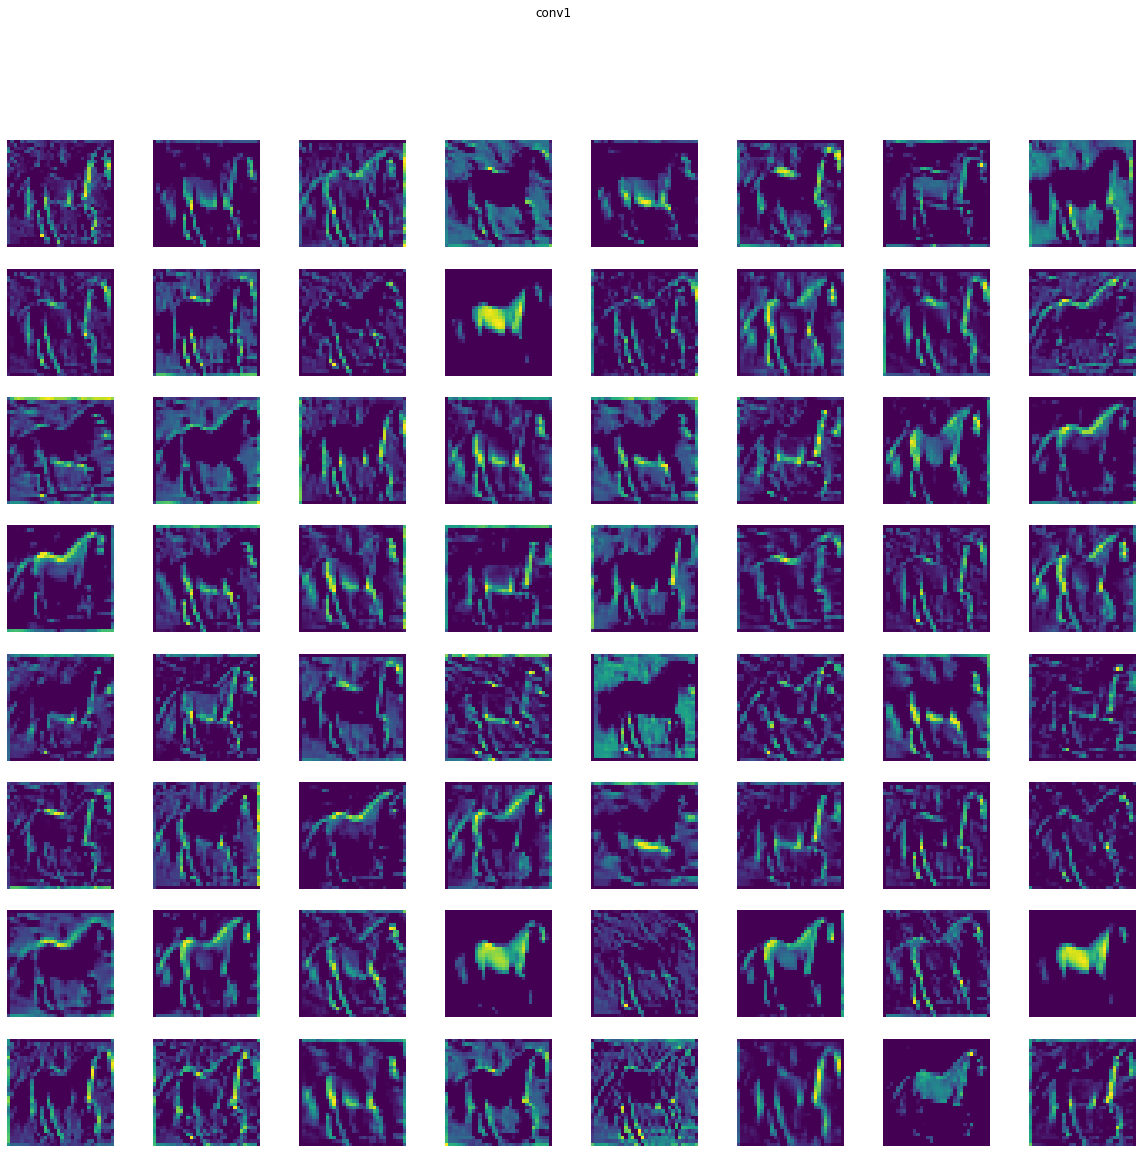

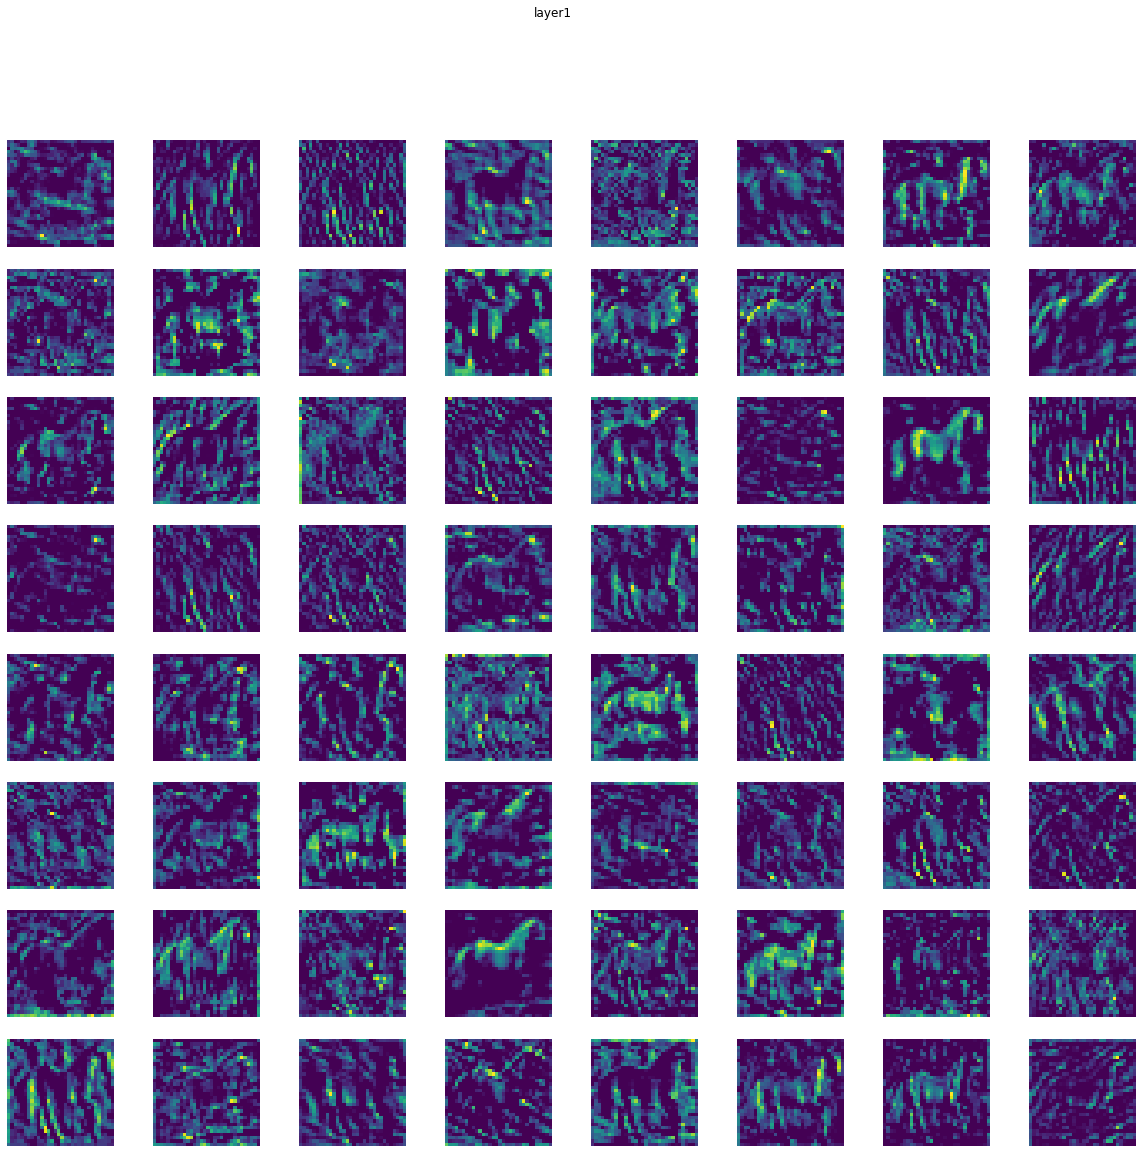

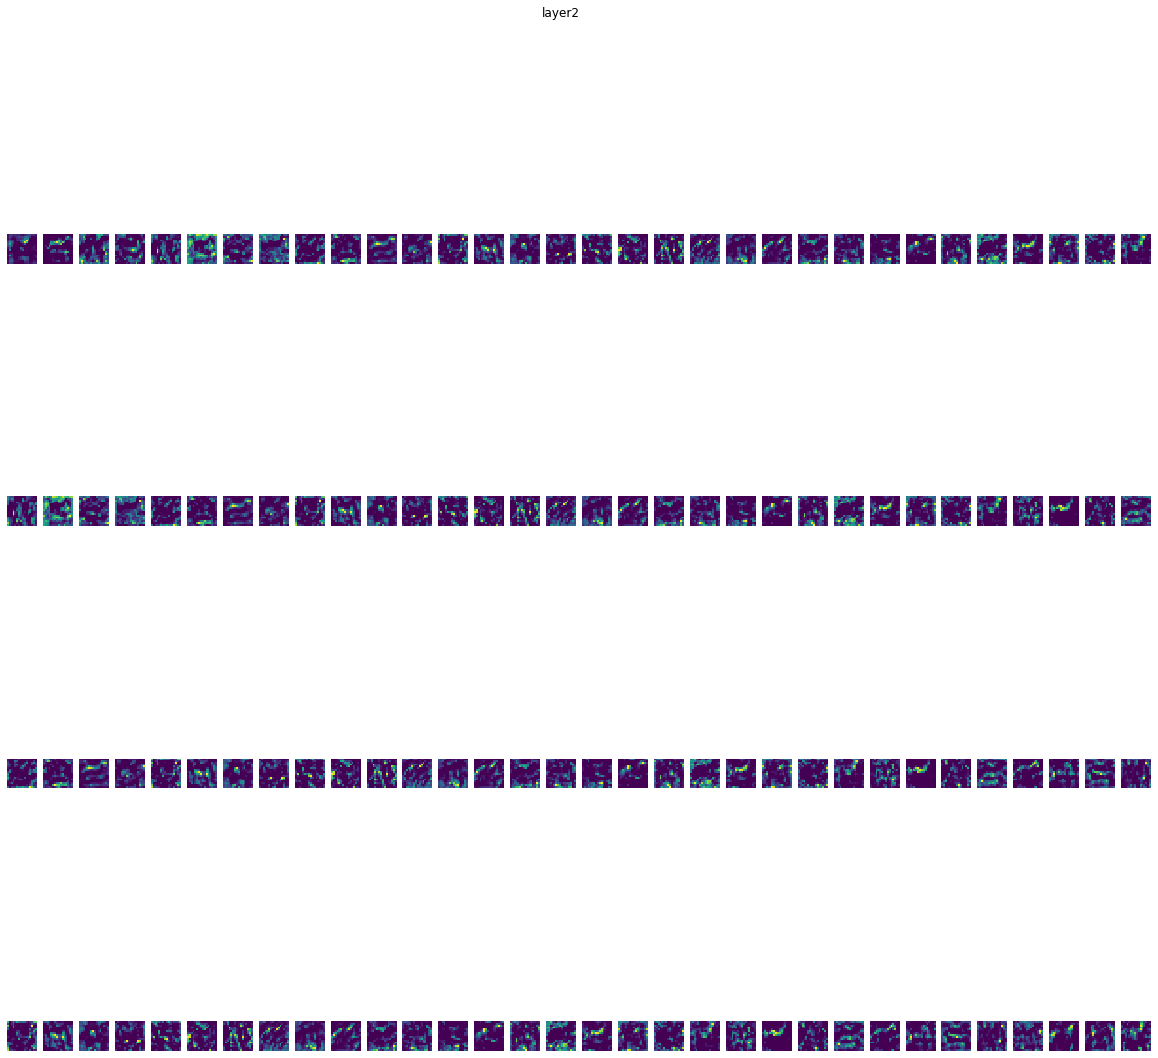

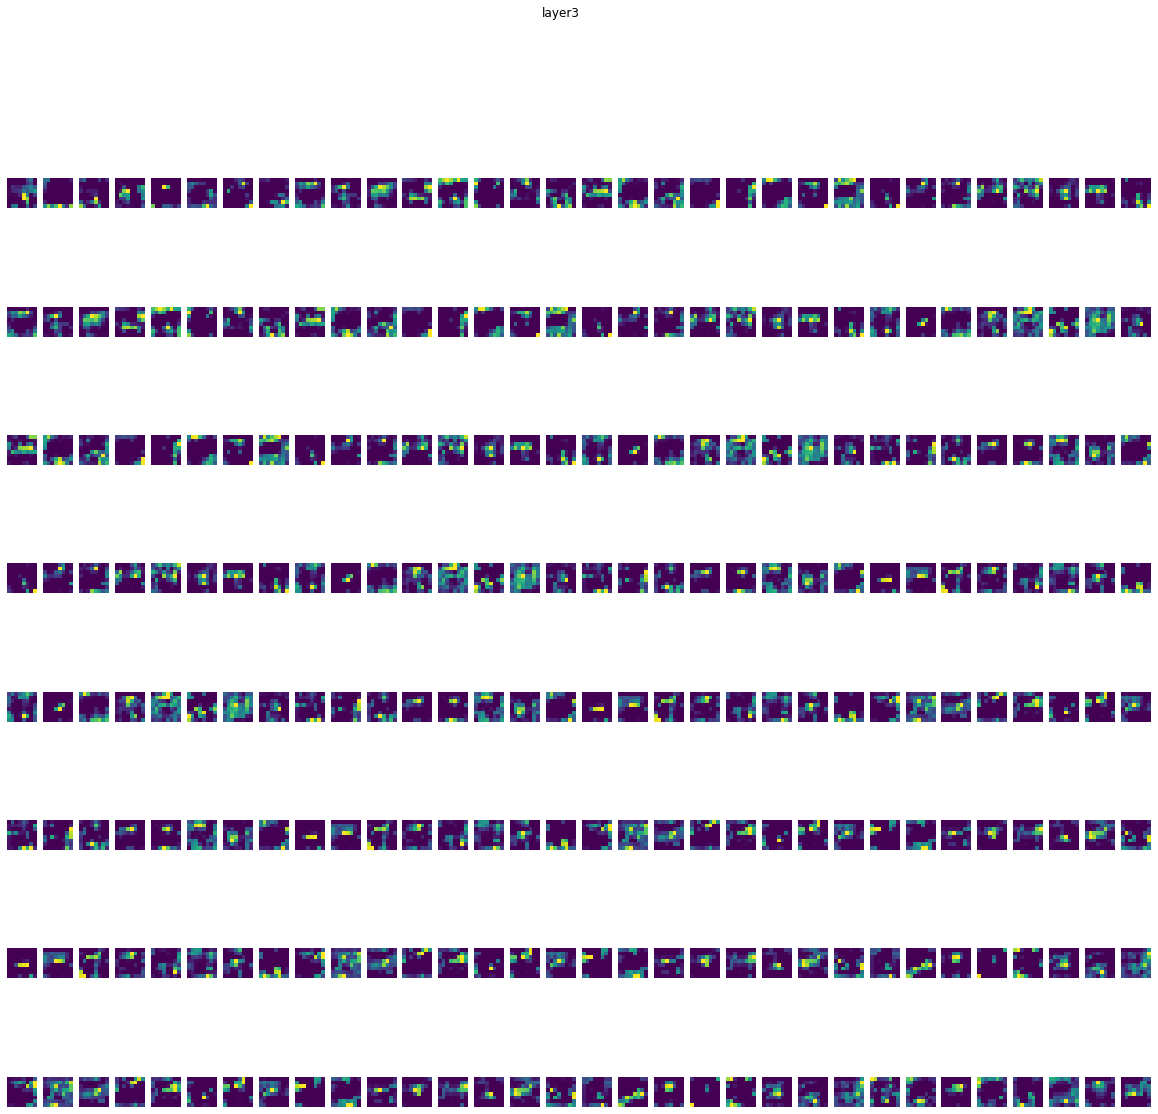

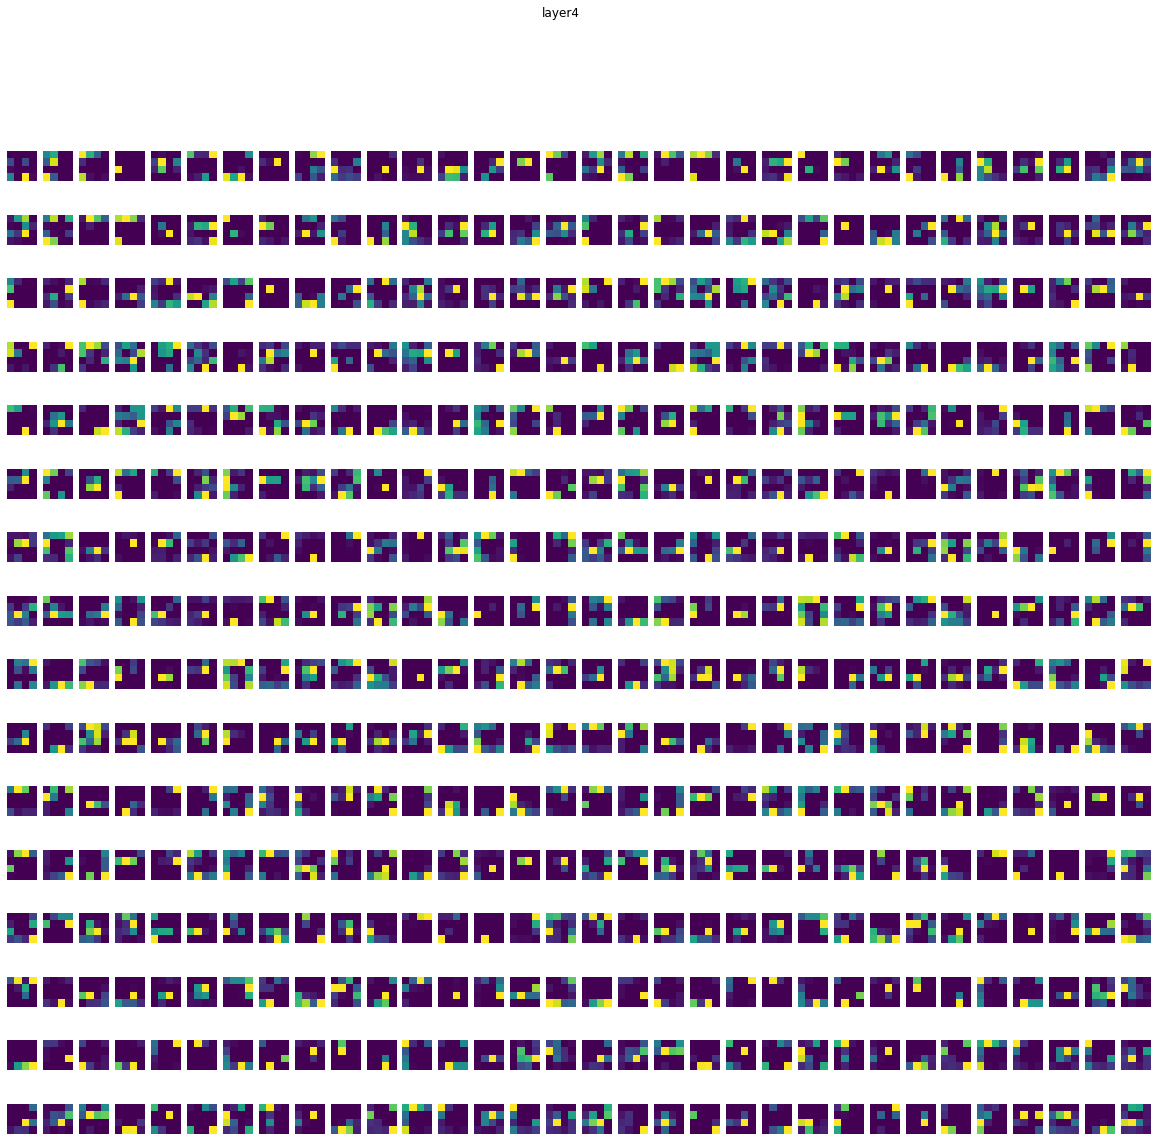

In [0]:
#!pip install matplotlib

import matplotlib.pyplot as plt

plt.tight_layout()


activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

vis_labels = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4']

for l in vis_labels:

    getattr(model, l).register_forward_hook(get_activation(l))
    
    
data, _ = cifar10_test[13]
data = data.unsqueeze_(0).to(device = device, dtype = dtype)

output = model(data)



for idx, l in enumerate(vis_labels):

    act = activation[l].squeeze()

    if idx < 2:
        ncols = 8
    else:
        ncols = 32
        
    nrows = act.size(0) // ncols
    
    fig, axarr = plt.subplots(nrows, ncols)
    fig.suptitle(l)
    fig.set_size_inches(20.5, 18.5)


    for i in range(nrows):
        for j in range(ncols):
            axarr[i, j].imshow(act[i * nrows + j].cpu())
            axarr[i, j].axis('off')